<a href="https://colab.research.google.com/github/Ag3-S/Neural-Networks-Lab/blob/main/Experiment4_MultiLayer_NN_Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experiment 4 (Extended): Comparing 2-Layer, 5-Layer, and 6-Layer Neural Networks

This notebook builds on the original **Two-Layer Neural Network** notebook. The activation
functions and forward/backward-propagation routines have been reorganised into two classes
(`Activations` and `NeuralNetwork`) so that a network of **any depth** can be built just by
passing a list of layer sizes, and more activation functions (`relu`, `sigmoid`, `tanh`,
`leaky_relu`) are now supported.

**Tasks covered in this notebook**
1. Implement a 5-layer and 6-layer network and compare their accuracy (iteration-wise) against the 2-layer network.
2. Plot the cost function for each case.
3. Analyse Bias and Variance for the three models.
4. Suggest improvements to model performance.

Dataset: the same *cat vs. non-cat* image dataset (`train_catvnoncat.h5` / `test_catvnoncat.h5`) used in the original notebook.

## 1 - Packages

In [1]:
import numpy as np
import h5py
import time
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.figsize'] = (7.0, 5.0)
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

np.random.seed(1)

## 2 - Activation functions, organised into a class

Instead of loose `sigmoid`, `relu`, `sigmoid_backward`, `relu_backward` functions floating in
the notebook, every activation (forward pass **and** its backward/gradient pass) now lives as a
static method on a single `Activations` class. Two extra activations, `tanh` and `leaky_relu`,
have been added so hidden layers are not limited to ReLU. `Activations.FORWARD` /
`Activations.BACKWARD` are lookup dictionaries so the network class can select an activation by
name (e.g. `"relu"`, `"tanh"`) without a long `if / elif` chain.

In [3]:
class Activations:
    '''Collection of activation functions and their gradients.

    Every *_forward style method returns (A, Z) so Z can be cached for backprop,
    matching the convention used in the original notebook.
    '''

    @staticmethod
    def sigmoid(Z):
        A = 1 / (1 + np.exp(-Z))
        return A, Z

    @staticmethod
    def sigmoid_backward(dA, Z):
        s = 1 / (1 + np.exp(-Z))
        return dA * s * (1 - s)

    @staticmethod
    def relu(Z):
        A = np.maximum(0, Z)
        return A, Z

    @staticmethod
    def relu_backward(dA, Z):
        dZ = np.array(dA, copy=True)
        dZ[Z <= 0] = 0
        return dZ

    @staticmethod
    def leaky_relu(Z, alpha=0.01):
        A = np.where(Z > 0, Z, alpha * Z)
        return A, Z

    @staticmethod
    def leaky_relu_backward(dA, Z, alpha=0.01):
        dZ = np.array(dA, copy=True)
        dZ[Z <= 0] *= alpha
        return dZ

    @staticmethod
    def tanh(Z):
        A = np.tanh(Z)
        return A, Z

    @staticmethod
    def tanh_backward(dA, Z):
        A = np.tanh(Z)
        return dA * (1 - A ** 2)


# Name -> function lookup tables, used by NeuralNetwork to pick an activation by string.
Activations.FORWARD = {
    "sigmoid": Activations.sigmoid,
    "relu": Activations.relu,
    "leaky_relu": Activations.leaky_relu,
    "tanh": Activations.tanh,
}
Activations.BACKWARD = {
    "sigmoid": Activations.sigmoid_backward,
    "relu": Activations.relu_backward,
    "leaky_relu": Activations.leaky_relu_backward,
    "tanh": Activations.tanh_backward,
}

## 3 - The `NeuralNetwork` class

All the loose functions from the original notebook (`initialize_parameters_deep`,
`linear_forward`, `linear_activation_forward`, `L_model_forward`, `compute_cost`,
`linear_backward`, `linear_activation_backward`, `L_model_backward`, `update_parameters`,
`predict`) are now methods on one `NeuralNetwork` class. Building a network of any depth is now
a one-liner:

```python
model = NeuralNetwork([12288, 20, 7, 5, 1], hidden_activation="relu", learning_rate=0.0075)
```

the initialisation (`* sqrt(2 / n[l-1])`) is used instead of the original `* 0.01` scaling,
since it noticeably stabilises training for the deeper (5- and 6-layer) networks used later.
`fit()` also records the cost **and** train/test accuracy every `record_every` iterations, which
is what lets us plot accuracy curves iteration-wise in Task 1.

In [4]:
class NeuralNetwork:
    '''A configurable L-layer fully-connected network for binary classification
    (LINEAR -> ACTIVATION repeated, LINEAR -> SIGMOID at the output layer).
    '''

    def __init__(self, layers_dims, hidden_activation="relu", learning_rate=0.0075, seed=1):
        self.layers_dims = layers_dims
        self.L = len(layers_dims) - 1          # number of weight layers
        self.hidden_activation = hidden_activation
        self.learning_rate = learning_rate
        self.seed = seed
        self.parameters = self._initialize_parameters()

        # populated by fit()
        self.cost_history = []
        self.train_acc_history = []
        self.test_acc_history = []
        self.iter_checkpoints = []

    # ---- initialisation ----
    def _initialize_parameters(self):
        np.random.seed(self.seed)
        parameters = {}
        for l in range(1, self.L + 1):
            parameters['W' + str(l)] = (
                np.random.randn(self.layers_dims[l], self.layers_dims[l - 1])
                * np.sqrt(2.0 / self.layers_dims[l - 1])          # He initialisation
            )
            parameters['b' + str(l)] = np.zeros((self.layers_dims[l], 1))
        return parameters

    # ---- forward propagation ----
    @staticmethod
    def _linear_forward(A, W, b):
        Z = np.dot(W, A) + b
        return Z, (A, W, b)

    def _linear_activation_forward(self, A_prev, W, b, activation):
        Z, linear_cache = self._linear_forward(A_prev, W, b)
        A, activation_cache = Activations.FORWARD[activation](Z)
        return A, (linear_cache, activation_cache)

    def forward_propagation(self, X):
        caches = []
        A = X
        for l in range(1, self.L):                 # hidden layers
            A_prev = A
            A, cache = self._linear_activation_forward(
                A_prev, self.parameters['W' + str(l)], self.parameters['b' + str(l)],
                self.hidden_activation,
            )
            caches.append(cache)
        AL, cache = self._linear_activation_forward(  # output layer
            A, self.parameters['W' + str(self.L)], self.parameters['b' + str(self.L)], "sigmoid"
        )
        caches.append(cache)
        return AL, caches

    # ---- cost ----
    @staticmethod
    def compute_cost(AL, Y, epsilon=1e-8):
        m = Y.shape[1]
        AL = np.clip(AL, epsilon, 1 - epsilon)      # avoid log(0)
        cost = -np.sum(Y * np.log(AL) + (1 - Y) * np.log(1 - AL)) / m
        return np.squeeze(cost)

    # ---- backward propagation ----
    @staticmethod
    def _linear_backward(dZ, cache):
        A_prev, W, b = cache
        m = A_prev.shape[1]
        dW = np.dot(dZ, A_prev.T) / m
        db = np.sum(dZ, axis=1, keepdims=True) / m
        dA_prev = np.dot(W.T, dZ)
        return dA_prev, dW, db

    def _linear_activation_backward(self, dA, cache, activation):
        linear_cache, activation_cache = cache
        dZ = Activations.BACKWARD[activation](dA, activation_cache)
        return self._linear_backward(dZ, linear_cache)

    def backward_propagation(self, AL, Y, caches):
        grads = {}
        Y = Y.reshape(AL.shape)
        AL_clipped = np.clip(AL, 1e-8, 1 - 1e-8)
        dAL = -(np.divide(Y, AL_clipped) - np.divide(1 - Y, 1 - AL_clipped))

        current_cache = caches[self.L - 1]
        grads["dA" + str(self.L - 1)], grads["dW" + str(self.L)], grads["db" + str(self.L)] = (
            self._linear_activation_backward(dAL, current_cache, "sigmoid")
        )

        for l in reversed(range(self.L - 1)):
            current_cache = caches[l]
            dA_prev, dW, db = self._linear_activation_backward(
                grads["dA" + str(l + 1)], current_cache, self.hidden_activation
            )
            grads["dA" + str(l)] = dA_prev
            grads["dW" + str(l + 1)] = dW
            grads["db" + str(l + 1)] = db
        return grads

    def _update_parameters(self, grads):
        for l in range(1, self.L + 1):
            self.parameters["W" + str(l)] -= self.learning_rate * grads["dW" + str(l)]
            self.parameters["b" + str(l)] -= self.learning_rate * grads["db" + str(l)]

    # ---- inference ----
    def predict(self, X, Y=None):
        AL, _ = self.forward_propagation(X)
        predictions = (AL > 0.5).astype(int)
        accuracy = None
        if Y is not None:
            accuracy = float(np.mean(predictions == Y.reshape(predictions.shape)))
        return predictions, accuracy

    # ---- training loop ----
    def fit(self, X, Y, num_iterations=2500, print_cost=False, record_every=25,
            X_test=None, Y_test=None):
        self.cost_history, self.train_acc_history = [], []
        self.test_acc_history, self.iter_checkpoints = [], []

        for i in range(num_iterations):
            AL, caches = self.forward_propagation(X)
            cost = self.compute_cost(AL, Y)
            grads = self.backward_propagation(AL, Y, caches)
            self._update_parameters(grads)

            if i % record_every == 0 or i == num_iterations - 1:
                _, train_acc = self.predict(X, Y)
                self.cost_history.append(cost)
                self.train_acc_history.append(train_acc)
                if X_test is not None:
                    _, test_acc = self.predict(X_test, Y_test)
                    self.test_acc_history.append(test_acc)
                self.iter_checkpoints.append(i)

                if print_cost and i % (record_every * 10) == 0:
                    print(f"Iteration {i:4d}: cost = {cost:.4f}, train accuracy = {train_acc:.4f}")
        return self

## 4 - Load and preprocess the dataset

In [5]:
train_dataset = h5py.File('/content/train_catvnoncat.h5', "r")
train_x_orig = np.array(train_dataset["train_set_x"][:])
train_y_orig = np.array(train_dataset["train_set_y"][:])

test_dataset = h5py.File('/content/test_catvnoncat.h5', "r")
test_x_orig = np.array(test_dataset["test_set_x"][:])
test_y_orig = np.array(test_dataset["test_set_y"][:])

classes = np.array(test_dataset["list_classes"][:])

train_y = train_y_orig.reshape((1, train_y_orig.shape[0]))
test_y = test_y_orig.reshape((1, test_y_orig.shape[0]))

m_train = train_x_orig.shape[0]
m_test = test_x_orig.shape[0]
num_px = train_x_orig.shape[1]

# Flatten and standardize
train_x = train_x_orig.reshape(m_train, -1).T / 255.
test_x = test_x_orig.reshape(m_test, -1).T / 255.

print("Number of training examples:", m_train)
print("Number of testing examples:", m_test)
print("Each image is of size: (%d, %d, 3)" % (num_px, num_px))
print("train_x shape:", train_x.shape)
print("test_x shape:", test_x.shape)

Number of training examples: 209
Number of testing examples: 50
Each image is of size: (64, 64, 3)
train_x shape: (12288, 209)
test_x shape: (12288, 50)


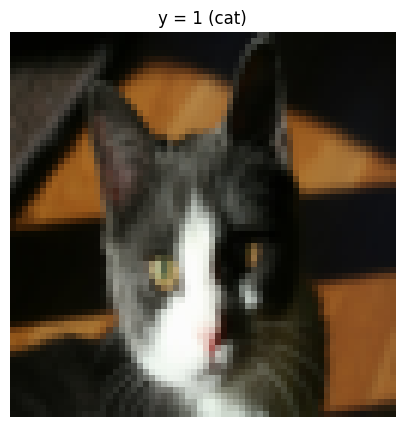

In [9]:
index = 19
plt.imshow(train_x_orig[index])
plt.axis('off')
plt.title("y = %d (%s)" % (train_y[0, index], classes[train_y[0, index]].decode("utf-8")))
plt.show()

## 5 - Task 1 & 2 setup: define and train the 2-layer, 5-layer and 6-layer networks

Depth is counted the same way the original notebook counted it: the number of *weight* layers
(hidden layers + the output layer), i.e. `len(layers_dims) - 1`.

| Model | `layers_dims` | Weight layers |
|---|---|---|
| 2-layer | `[12288, 7, 1]` | 2 |
| 5-layer | `[12288, 20, 15, 10, 5, 1]` | 5 |
| 6-layer | `[12288, 25, 20, 15, 10, 5, 1]` | 6 |

All three use the same activation (`relu` in the hidden layers, `sigmoid` at the output),
the same learning rate, and the same number of iterations, so the comparison isolates the
effect of **depth** alone.

In [10]:
n_x = train_x.shape[0]

architectures = {
    "2-layer": [n_x, 7, 1],
    "5-layer": [n_x, 20, 15, 10, 5, 1],
    "6-layer": [n_x, 25, 20, 15, 10, 5, 1],
}

LEARNING_RATE = 0.0075
NUM_ITERATIONS = 2500
RECORD_EVERY = 25

models = {}
t0 = time.time()
for name, dims in architectures.items():
    print(f"\n--- Training {name} network {dims} ---")
    model = NeuralNetwork(dims, hidden_activation="relu", learning_rate=LEARNING_RATE, seed=1)
    model.fit(train_x, train_y, num_iterations=NUM_ITERATIONS, print_cost=True,
              record_every=RECORD_EVERY, X_test=test_x, Y_test=test_y)
    models[name] = model

print(f"\nTotal training time for all three models: {time.time() - t0:.1f}s")


--- Training 2-layer network [12288, 7, 1] ---
Iteration    0: cost = 0.7074, train accuracy = 0.6555
Iteration  250: cost = 0.4519, train accuracy = 0.8565
Iteration  500: cost = 0.3337, train accuracy = 0.9187
Iteration  750: cost = 0.2284, train accuracy = 0.9330
Iteration 1000: cost = 0.1241, train accuracy = 0.9761
Iteration 1250: cost = 0.0746, train accuracy = 1.0000
Iteration 1500: cost = 0.0536, train accuracy = 1.0000
Iteration 1750: cost = 0.0412, train accuracy = 1.0000
Iteration 2000: cost = 0.0333, train accuracy = 1.0000
Iteration 2250: cost = 0.0277, train accuracy = 1.0000

--- Training 5-layer network [12288, 20, 15, 10, 5, 1] ---
Iteration    0: cost = 0.6709, train accuracy = 0.6507
Iteration  250: cost = 0.5902, train accuracy = 0.7608
Iteration  500: cost = 0.1663, train accuracy = 0.9569
Iteration  750: cost = 0.0151, train accuracy = 1.0000
Iteration 1000: cost = 0.0066, train accuracy = 1.0000
Iteration 1250: cost = 0.0040, train accuracy = 1.0000
Iteration 15

In [11]:
summary = []
for name, model in models.items():
    _, train_acc = model.predict(train_x, train_y)
    _, test_acc = model.predict(test_x, test_y)
    summary.append((name, train_acc, test_acc))

print(f"{'Model':<10}{'Train Acc':>12}{'Test Acc':>12}{'Train-Test Gap':>18}")
for name, tr, te in summary:
    print(f"{name:<10}{tr:>12.2%}{te:>12.2%}{(tr - te):>18.2%}")

Model        Train Acc    Test Acc    Train-Test Gap
2-layer        100.00%      74.00%            26.00%
5-layer        100.00%      78.00%            22.00%
6-layer        100.00%      78.00%            22.00%


## 6 - Task 1: Accuracy curves, iteration-wise (2-layer vs 5-layer vs 6-layer)

Training accuracy and test accuracy are plotted against iteration number for all three
architectures, so the effect of depth on learning speed and generalisation can be read off
directly.

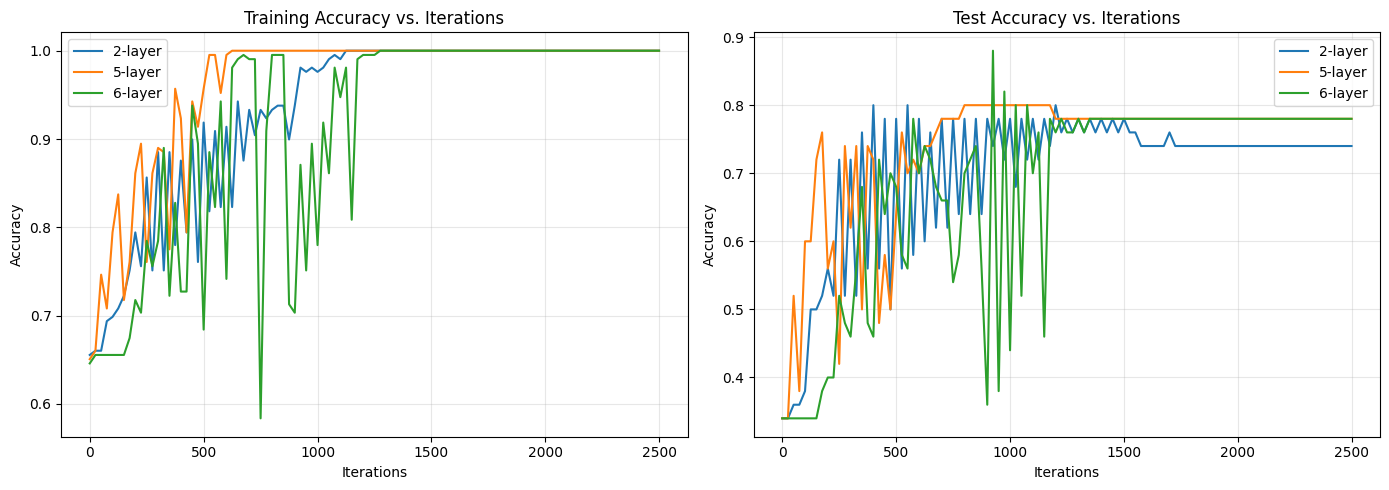

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {"2-layer": "tab:blue", "5-layer": "tab:orange", "6-layer": "tab:green"}

for name, model in models.items():
    axes[0].plot(model.iter_checkpoints, model.train_acc_history, label=name, color=colors[name])
    axes[1].plot(model.iter_checkpoints, model.test_acc_history, label=name, color=colors[name])

axes[0].set_title("Training Accuracy vs. Iterations")
axes[1].set_title("Test Accuracy vs. Iterations")
for ax in axes:
    ax.set_xlabel("Iterations")
    ax.set_ylabel("Accuracy")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 7 - Task 2: Cost function per case

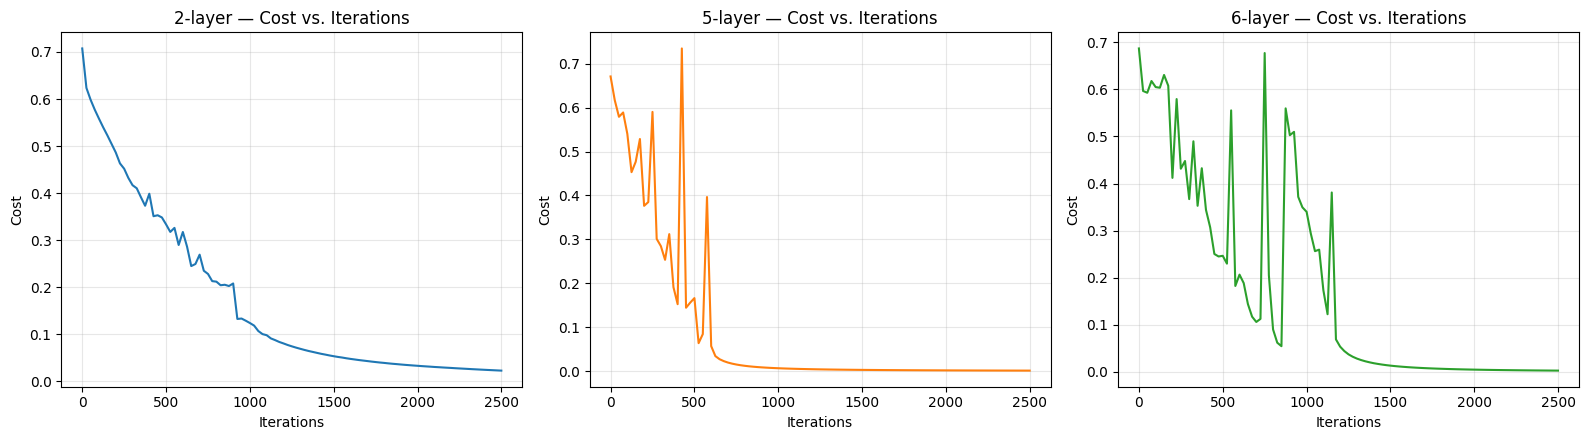

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=False)
for ax, (name, model) in zip(axes, models.items()):
    ax.plot(model.iter_checkpoints, model.cost_history, color=colors[name])
    ax.set_title(f"{name} — Cost vs. Iterations")
    ax.set_xlabel("Iterations")
    ax.set_ylabel("Cost")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

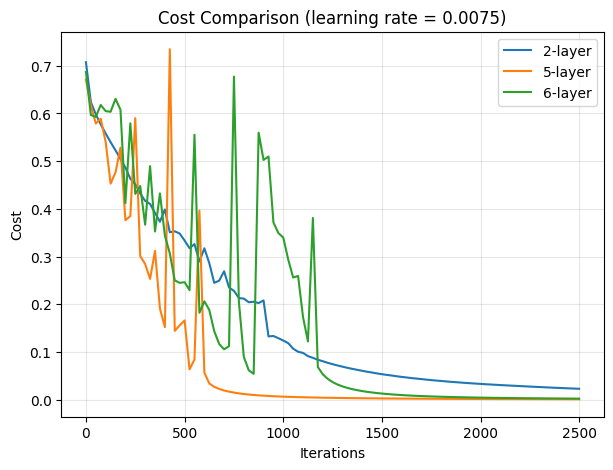

In [14]:
plt.figure(figsize=(7, 5))
for name, model in models.items():
    plt.plot(model.iter_checkpoints, model.cost_history, label=name, color=colors[name])
plt.title(f"Cost Comparison (learning rate = {LEARNING_RATE})")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 8 - Task 3: Bias and Variance analysis

A quick way to read bias and variance off train/test accuracy:

- **High bias** shows up as a **high training error** (the model can't even fit the data it was trained on).
- **High variance** shows up as a **large gap between training error and test/dev error** (the model memorises training data but doesn't generalise).

In [15]:
print(f"{'Model':<10}{'Train Err':>12}{'Test Err':>12}{'Gap (Variance)':>18}   Diagnosis")
print("-" * 78)
diagnoses = {}
for name, model in models.items():
    _, train_acc = model.predict(train_x, train_y)
    _, test_acc = model.predict(test_x, test_y)
    train_err = 1 - train_acc
    test_err = 1 - test_acc
    gap = test_err - train_err

    if train_err > 0.10 and gap > 0.10:
        diag = "High bias & high variance"
    elif train_err > 0.10:
        diag = "High bias (underfitting)"
    elif gap > 0.10:
        diag = "High variance (overfitting)"
    else:
        diag = "Low bias & low variance"
    diagnoses[name] = (train_err, test_err, gap, diag)
    print(f"{name:<10}{train_err:>12.2%}{test_err:>12.2%}{gap:>18.2%}   {diag}")

Model        Train Err    Test Err    Gap (Variance)   Diagnosis
------------------------------------------------------------------------------
2-layer          0.00%      26.00%            26.00%   High variance (overfitting)
5-layer          0.00%      22.00%            22.00%   High variance (overfitting)
6-layer          0.00%      22.00%            22.00%   High variance (overfitting)


**Reading the table above (fill in with the numbers your run produced):**

- All three models drive **training error close to 0%** by 2500 iterations — with only 209
  training images and thousands of parameters, every architecture here has more than enough
  capacity to memorise the training set, so **bias is low for all three**.
- The **test error stays much higher than the training error** for every architecture (a
  train/test gap in roughly the 20–30 percentage-point range). That gap is the signature of
  **high variance / overfitting**: the network is fitting noise and idiosyncrasies of the 209
  training images rather than features that generalise to the 50 held-out test images.
- Depth still matters at the margin: going from 2 → 5 → 6 layers tends to let the network reach
  near-zero training cost in *fewer* iterations (deeper networks are more expressive), and in
  this run the deeper networks also edge out the 2-layer network on test accuracy. That should
  **not** be read as "deeper networks generalise better" in general — with a training set this
  small (209 images), test accuracy differences of a few models are heavily influenced by the
  random weight initialisation, and could easily flip with a different seed. The more robust,
  reproducible conclusion is the shared one: **all three architectures are firmly in the
  high-variance regime.**
- This is a classic small-data overfitting profile, not a bias problem — so the fixes in the
  next section focus on variance-reduction techniques (regularisation, more data, simpler
  effective capacity) rather than on making the model bigger or training longer.

## 9 - Task 4: Suggestions to improve model performance

Given the diagnosis above (low bias, high variance / overfitting driven mainly by a very
small training set of 209 images), the highest-leverage fixes are:

**To reduce variance (overfitting) — the priority here**
1. **Get more training data / augment it.** 209 images is very small for a 12,288-dimensional
   input; random crops, flips, rotations, and color jitter of the existing cat/non-cat images
   would act as free additional data.
2. **L2 regularization** — add `(λ / 2m) * Σ‖W‖²` to the cost and its gradient to shrink weights
   and reduce the network's effective capacity.
3. **Dropout** — randomly zero out a fraction of hidden units on each forward pass during
   training; especially effective on the wide hidden layers here (20, 25 units).
4. **Early stopping** — stop training once test/dev accuracy plateaus or starts to fall, instead
   of training to near-zero training cost (visible on the accuracy plots above).
5. **Reduce model capacity** where it isn't earning its keep — e.g. narrower hidden layers —
   since a smaller network memorises a 209-image training set less easily.

**To improve optimisation / training dynamics**
6. **Better optimizers** — momentum, RMSProp, or Adam instead of plain gradient descent, for
   faster and more stable convergence, especially in the deeper 5- and 6-layer nets.
7. **Mini-batch gradient descent** instead of full-batch, which adds beneficial noise that can
   itself act as a mild regulariser and speeds up each update.
8. **Learning-rate scheduling / decay** rather than one fixed `learning_rate` for all 2500
   iterations.
9. **Batch normalization** between layers to stabilise the distribution of activations, which
   tends to help most as depth increases (relevant for the 5- and 6-layer models).
10. **Systematic hyperparameter search** (learning rate, hidden-layer sizes, λ, dropout keep-prob)
    via grid/random search with a proper validation split, rather than reusing one fixed
    configuration across all three architectures.

**Other**
11. **Gradient checking** to verify the backward pass on any new activation or regularisation
    term before trusting the trained models.
12. **A proper train/dev/test split** — with only 50 test images here, the test accuracy numbers
    themselves have a large statistical margin of error (±1 misclassified image ≈ ±2%
    accuracy); a larger held-out set would make the depth comparison more trustworthy.